In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import numpy as np
import re
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


def load_perceptions_dataset(data_dir):
    """Load perception.json files from clean/dirty/occupied folders.

    clean + dirty -> 0 (unoccupied)
    occupied -> 1 (occupied)
    """
    label_map = {'clean': 0, 'dirty': 0, 'occupied': 1}
    features_list = []
    targets_list = []
    groups_list = []

    for label_name, target in label_map.items():
        label_dir = os.path.join(data_dir, label_name)
        if not os.path.isdir(label_dir):
            continue
        for folder_name in sorted(os.listdir(label_dir)):
            perc_path = os.path.join(label_dir, folder_name, "perception.json")
            if not os.path.exists(perc_path):
                continue
            with open(perc_path) as f:
                perc = json.load(f)
            feat = engineer_features(perc)
            if feat is not None:
                features_list.append(feat)
                targets_list.append(target)
                # Extract group ID to prevent temporal leakage
                group_id = re.sub(r"_t\d{4}$", "", folder_name)
                groups_list.append(group_id)

    return np.array(features_list), np.array(targets_list), np.array(groups_list)


def engineer_features(perc):
    """Extract features from a single perception.json."""
    s = perc.get('scalars')
    people = perc.get('people', [])

    if s is None:
        return None

    pc = s['person_count']                          # [int, int, int]
    max_overlap = s['max_overlap_frac_of_person']   # [float, float, float]
    overlap_sum = s['overlap_sum']                   # [float, float, float]
    min_dist = s['min_distance_norm']                # [float, float, float]
    entering = s['entering']                         # [int, int]
    leaving = s['leaving']                           # [int, int]

    # --- Person count signals ---
    pc_mean = np.mean(pc)
    pc_max = max(pc)
    pc_min = min(pc)
    pc_trend = pc[2] - pc[0]           # positive = people arriving
    pc_any = int(any(p > 0 for p in pc))
    pc_all = int(all(p > 0 for p in pc))  # someone in every frame

    # --- Overlap signals ---
    overlap_max = max(max_overlap)
    overlap_mean = np.mean(max_overlap)
    overlap_sum_max = max(overlap_sum)
    overlap_sum_mean = np.mean(overlap_sum)

    # --- Distance signals ---
    dist_min = min(min_dist)           # closest anyone gets to table center
    dist_mean = np.mean(min_dist)

    # --- Motion signals ---
    mean_disp = s['mean_displacement'] or 0.0
    max_disp = s['max_displacement'] or 0.0
    persistent = s['persistent_count']  # people in ALL 3 frames = seated

    # --- Entering/leaving ---
    total_entering = sum(entering)
    total_leaving = sum(leaving)
    net_flow = total_entering - total_leaving

    # --- Per-person aggregates ---
    if people:
        scores = [p['score'] for p in people]
        overlaps = [p['overlap_frac_of_person'] for p in people]
        displacements = [p['displacement_from_prev'] for p in people if p['displacement_from_prev'] is not None]
        max_score = max(scores)
        mean_overlap_person = np.mean(overlaps)
        mean_disp_person = np.mean(displacements) if displacements else 0.0
        n_high_overlap = sum(1 for o in overlaps if o > 0.5)
    else:
        max_score = 0.0
        mean_overlap_person = 0.0
        mean_disp_person = 0.0
        n_high_overlap = 0

    # --- Seated heuristic: persistent + low displacement + high overlap ---
    seated_signal = persistent * (1.0 - min(mean_disp * 10, 1.0)) * overlap_mean

    return [
        pc_mean, pc_max, pc_min, pc_trend, pc_any, pc_all,
        overlap_max, overlap_mean, overlap_sum_max, overlap_sum_mean,
        dist_min, dist_mean,
        mean_disp, max_disp, persistent,
        total_entering, total_leaving, net_flow,
        max_score, mean_overlap_person, mean_disp_person, n_high_overlap,
        seated_signal,
    ]


In [ ]:
import numpy as np

# Your provided sample data
sample_perc = {
    "people": [
        {
            "frame_index": 0,
            "track_id": "t0",
            "centroid_x": 0.4231,
            "centroid_y": 0.6102,
            "bbox_xyxy": [320.0, 410.0, 480.5, 690.2],
            "overlap_frac_of_person": 0.7812,
            "overlap_frac_of_table": 0.3104,
            "distance_norm": 0.0823,
            "displacement_from_prev": None,
            "score": 0.943
        },
        {
            "frame_index": 1,
            "track_id": "t0",
            "centroid_x": 0.4248,
            "centroid_y": 0.6089,
            "bbox_xyxy": [322.1, 408.3, 482.0, 688.7],
            "overlap_frac_of_person": 0.7956,
            "overlap_frac_of_table": 0.3201,
            "distance_norm": 0.0791,
            "displacement_from_prev": 0.0021,
            "score": 0.951
        }
    ],
    "scalars": {
        "person_count": [1, 1, 1],
        "max_overlap_frac_of_person": [0.7812, 0.7956, 0.8010],
        "overlap_sum": [0.7812, 0.7956, 0.8010],
        "min_distance_norm": [0.0823, 0.0791, 0.0774],
        "mean_displacement": 0.0019,
        "max_displacement": 0.0021,
        "entering": [0, 0],
        "leaving": [0, 0],
        "persistent_count": 1
    }
}

# 1. Engineer features using the existing function
feat_vector = engineer_features(sample_perc)

if feat_vector:
    # 2. Reshape for the model (expects a 2D array)
    feat_input = np.array(feat_vector).reshape(1, -1)

    # 3. Predict using the trained xgb model
    prediction = xgb.predict(feat_input)[0]
    probability = xgb.predict_proba(feat_input)[0][1]

    label = "occupied" if prediction == 1 else "unoccupied"
    print(f"Prediction: {label} ({prediction})")
    print(f"Probability of occupancy: {probability:.4f}")
else:
    print("Error: Feature engineering failed on the sample.")

Prediction: occupied (1)
Probability of occupancy: 0.5129


In [ ]:
xgb.save_model('xgboost_model.json')
print("XGBoost model saved to xgboost_model.json")

XGBoost model saved to xgboost_model.json


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Random Forest (Robust alternative to XGBoost)
rf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)
rf.fit(features_train, targets_train)

# 2. Tuned MLP (Requires Scaling)
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(128, 64), alpha=0.01, max_iter=1000, random_state=42))
])
mlp_pipe.fit(features_train, targets_train)

# Comparison
models = {
    'XGBoost': xgb.predict(features_test),
    'Random Forest': rf.predict(features_test),
    'MLP (Neural Net)': mlp_pipe.predict(features_test)
}

print("Model Comparison (Accuracy) on 10k sample scale:")
for name, preds in models.items():
    acc = accuracy_score(targets_test, preds)
    print(f"{name:15}: {acc:.4f}")

Model Comparison (Accuracy) on 10k sample scale:
XGBoost        : 0.7821
Random Forest  : 0.8462
MLP (Neural Net): 0.8590


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

FEATURE_NAMES = [
    'pc_mean', 'pc_max', 'pc_min', 'pc_trend', 'pc_any', 'pc_all',
    'overlap_max', 'overlap_mean', 'overlap_sum_max', 'overlap_sum_mean',
    'dist_min', 'dist_mean',
    'mean_disp', 'max_disp', 'persistent_count',
    'total_entering', 'total_leaving', 'net_flow',
    'max_score', 'mean_overlap_person', 'mean_disp_person', 'n_high_overlap',
    'seated_signal',
]

# --- Load and split ---
features, targets, groups = load_perceptions_dataset("/content/drive/Shared drives/shire drive/SHIRELABELING")
print(f"Loaded {len(features)} samples: {sum(targets)} occupied, {len(targets)-sum(targets)} unoccupied")

# Use GroupShuffleSplit to prevent data leakage
# Allocate 15% for testing
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(features, targets, groups))

features_train_val = features[train_val_idx]
targets_train_val = targets[train_val_idx]
groups_train_val = groups[train_val_idx]

features_test = features[test_idx]
targets_test = targets[test_idx]

# Split remaining data (85%) into train and validation sets
# We want ~15% of the total data for validation, so 0.15 / 0.85 ≈ 0.176
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx, val_idx = next(gss_val.split(features_train_val, targets_train_val, groups_train_val))

features_train = features_train_val[train_idx]
targets_train = targets_train_val[train_idx]
features_val = features_train_val[val_idx]
targets_val = targets_train_val[val_idx]

print(f"Train set: {len(features_train)} | Val set: {len(features_val)} | Test set: {len(features_test)}")


Loaded 2467 samples: 862 occupied, 1605 unoccupied
Train set: 1766 | Val set: 389 | Test set: 312


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After mounting, your data folder is accessible at:
# /content/drive/Shared drives/shire drive/SHIRELABELING


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# --- Train Tiny MLP ---
# MLPs require scaled features to converge properly and quickly.
mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(32, 16), # Even smaller capacity network
        activation='relu',
        max_iter=1000,
        random_state=42,
        early_stopping=True,         # Stops training if validation score stops improving
        validation_fraction=0.15
    ))
])

print("Training Tiny MLP...")
mlp_model.fit(features_train, targets_train)

# --- Evaluate ---
print("\nTest results:")
preds = mlp_model.predict(features_test)
print(classification_report(targets_test, preds, target_names=['unoccupied', 'occupied']))


Training Tiny MLP...

Test results:
              precision    recall  f1-score   support

  unoccupied       0.98      0.83      0.90       234
    occupied       0.65      0.95      0.77        78

    accuracy                           0.86       312
   macro avg       0.82      0.89      0.84       312
weighted avg       0.90      0.86      0.87       312



In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 1. Handle Class Imbalance mathematically
# Calculate ratio of negative (unoccupied: 0) to positive (occupied: 1) classes
num_unoccupied = np.sum(targets_train == 0)
num_occupied = np.sum(targets_train == 1)
balance_ratio = num_unoccupied / num_occupied
print(f"Class balance ratio (Unoccupied/Occupied): {balance_ratio:.2f}")

# 2. Define the State-of-the-Art Individual Models

# Model A: Advanced XGBoost (Tree-based, boosted)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=balance_ratio, # Fixes the precision/recall imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Model B: Robust Random Forest (Tree-based, bagging)
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced', # Fixes the precision/recall imbalance
    random_state=42
)

# Model C: Tuned MLP Neural Network (requires scaled features)
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        alpha=0.01,          # L2 regularization to prevent overfitting
        max_iter=1500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15
    ))
])

# 3. Create the "Perfect" Ensemble Architecture
# A Soft Voting Classifier averages the predicted probabilities of all 3 models
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('mlp', mlp_pipe)
    ],
    voting='soft'
)

# 4. Train the Ensemble
print("Training the Ultimate Ensemble Architecture...")
ensemble_model.fit(features_train, targets_train)

# 5. Evaluate on the Test Set
print("\n--- Final Ensemble Test Results ---")
preds = ensemble_model.predict(features_test)
print(classification_report(targets_test, preds, target_names=['unoccupied', 'occupied']))
print(f"Overall Accuracy: {accuracy_score(targets_test, preds):.4f}")

Class balance ratio (Unoccupied/Occupied): 1.63
Training the Ultimate Ensemble Architecture...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:07:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Final Ensemble Test Results ---
              precision    recall  f1-score   support

  unoccupied       0.99      0.82      0.89       234
    occupied       0.64      0.97      0.77        78

    accuracy                           0.86       312
   macro avg       0.81      0.90      0.83       312
weighted avg       0.90      0.86      0.86       312

Overall Accuracy: 0.8558


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

# Define logical feature groups based on your engineer_features function
feature_groups = {
    'Person Count': ['pc_mean', 'pc_max', 'pc_min', 'pc_trend', 'pc_any', 'pc_all'],
    'Overlap': ['overlap_max', 'overlap_mean', 'overlap_sum_max', 'overlap_sum_mean', 'mean_overlap_person', 'n_high_overlap'],
    'Distance': ['dist_min', 'dist_mean'],
    'Motion': ['mean_disp', 'max_disp', 'mean_disp_person'],
    'Entering/Leaving': ['total_entering', 'total_leaving', 'net_flow'],
    'Other/Heuristics': ['persistent_count', 'max_score', 'seated_signal']
}

print("--- Feature Ablation Study (Random Forest) ---\n")

# Baseline (All features)
rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_base.fit(features_train, targets_train)
preds_base = rf_base.predict(features_test)
base_f1 = f1_score(targets_test, preds_base)
print(f"Baseline (All Features) F1-Score: {base_f1:.4f}\n")

# Leave-one-group-out ablation
for group_name, group_features in feature_groups.items():
    # Find indices of features NOT in the current group
    indices_to_keep = [i for i, f in enumerate(FEATURE_NAMES) if f not in group_features]

    # Filter training and testing data
    X_train_ablated = features_train[:, indices_to_keep]
    X_test_ablated = features_test[:, indices_to_keep]

    # Train and evaluate
    rf_ablated = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_ablated.fit(X_train_ablated, targets_train)
    preds = rf_ablated.predict(X_test_ablated)

    # Calculate metrics
    f1 = f1_score(targets_test, preds)
    precision = precision_score(targets_test, preds)
    recall = recall_score(targets_test, preds)

    # Compare to baseline
    diff = f1 - base_f1
    impact = "📉 Dropped" if diff < 0 else "📈 Improved"

    print(f"Without {group_name}:")
    print(f"  F1: {f1:.4f} ({impact} by {abs(diff):.4f}) | Precision: {precision:.4f} | Recall: {recall:.4f}")


--- Feature Ablation Study (Random Forest) ---

Baseline (All Features) F1-Score: 0.7638

Without Person Count:
  F1: 0.7755 (📈 Improved by 0.0117) | Precision: 0.6441 | Recall: 0.9744
Without Overlap:
  F1: 0.7488 (📉 Dropped by 0.0151) | Precision: 0.6080 | Recall: 0.9744
Without Distance:
  F1: 0.7716 (📈 Improved by 0.0078) | Precision: 0.6387 | Recall: 0.9744
Without Motion:
  F1: 0.7677 (📈 Improved by 0.0039) | Precision: 0.6333 | Recall: 0.9744
Without Entering/Leaving:
  F1: 0.7600 (📉 Dropped by 0.0038) | Precision: 0.6230 | Recall: 0.9744
Without Other/Heuristics:
  F1: 0.7600 (📉 Dropped by 0.0038) | Precision: 0.6230 | Recall: 0.9744


In [ ]:
from sklearn.metrics import classification_report

# 1. Test a simple hardcoded rule: If maximum person count > 0, then Occupied.
p_count_idx = FEATURE_NAMES.index('pc_max')
# Predict 1 if pc_max > 0, else 0
hardcoded_preds = (features_test[:, p_count_idx] > 0).astype(int)

print("--- Hardcoded Baseline (If Person Count > 0) ---")
print(classification_report(targets_test, hardcoded_preds, target_names=['unoccupied', 'occupied']))

# Calculate how much better the Ensemble did vs the Hardcoded rule
ensemble_acc = accuracy_score(targets_test, preds)
hardcoded_acc = accuracy_score(targets_test, hardcoded_preds)
print(f"Hardcoded Accuracy: {hardcoded_acc:.4f}")
print(f"Ensemble Accuracy:  {ensemble_acc:.4f} (Improvement: +{(ensemble_acc - hardcoded_acc)*100:.1f}%)\n")

--- Hardcoded Baseline (If Person Count > 0) ---
              precision    recall  f1-score   support

  unoccupied       1.00      0.45      0.62       234
    occupied       0.38      1.00      0.55        78

    accuracy                           0.59       312
   macro avg       0.69      0.72      0.58       312
weighted avg       0.84      0.59      0.60       312

Hardcoded Accuracy: 0.5865
Ensemble Accuracy:  0.8462 (Improvement: +26.0%)



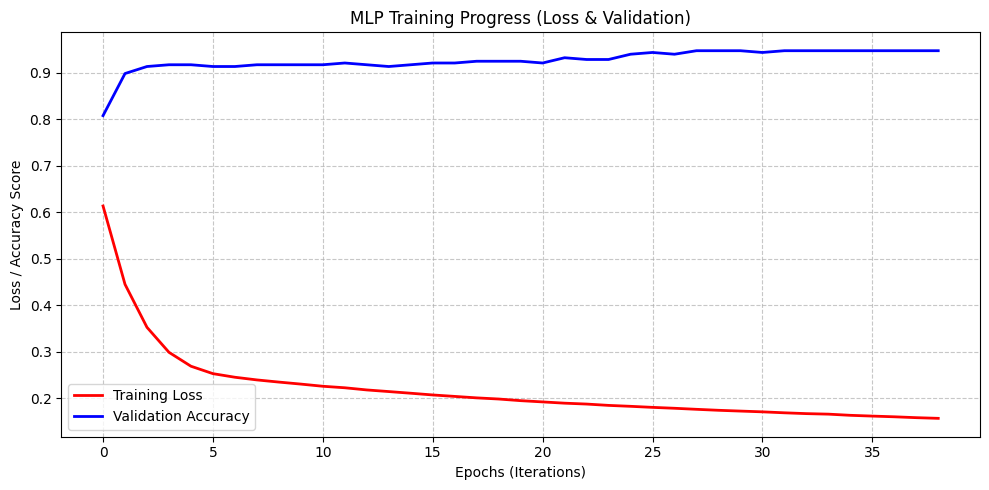

In [ ]:
import matplotlib.pyplot as plt

# 2. Plot the MLP Loss Curve
# Extract the trained MLP from the pipeline INSIDE the fitted ensemble
fitted_mlp_pipe = ensemble_model.named_estimators_['mlp']
mlp_classifier = fitted_mlp_pipe.named_steps['mlp']

plt.figure(figsize=(10, 5))

# Plot Training Loss
plt.plot(mlp_classifier.loss_curve_, label='Training Loss', color='red', linewidth=2)

# If early stopping is enabled, it tracks validation scores
if mlp_classifier.early_stopping:
    # Validation scores are accuracy by default, so we plot it on a secondary axis or same axis
    plt.plot(mlp_classifier.validation_scores_, label='Validation Accuracy', color='blue', linewidth=2)

plt.title('MLP Training Progress (Loss & Validation)')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Loss / Accuracy Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

# 1. Adjust the Decision Threshold
# Get probabilities for the positive class (Occupied) from the ensemble
probs = ensemble_model.predict_proba(features_test)[:, 1]

print("--- Threshold Tuning (Occupied Class) ---")
print("Goal: Increase precision (reduce false positives) without killing recall.\n")
thresholds = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]

for t in thresholds:
    custom_preds = (probs >= t).astype(int)
    precision = precision_score(targets_test, custom_preds, zero_division=0)
    recall = recall_score(targets_test, custom_preds)
    print(f"Threshold {t:.2f} -> Precision: {precision:.2f} | Recall: {recall:.2f}")

print("\n=========================================\n")

# 2. Error Analysis: Find the False Positives
print("--- Error Analysis: False Positives ---")
# We need the group names for the test set to know WHICH folders failed
groups_test = groups[test_idx]

# False Positive: Model predicted 1 (Occupied), but actual target is 0 (Unoccupied)
false_positives_idx = np.where((preds == 1) & (targets_test == 0))[0]

print(f"Total False Positives found in Test Set: {len(false_positives_idx)}")
print("Here are 10 examples of folders the model got wrong. Check the raw videos or JSONs for these:")
for i, idx in enumerate(false_positives_idx[:10]):
    folder_name = groups_test[idx]
    model_confidence = probs[idx]
    print(f"{i+1}. Confidence: {model_confidence:.2f} | Folder: {folder_name}")

--- Threshold Tuning (Occupied Class) ---
Goal: Increase precision (reduce false positives) without killing recall.

Threshold 0.50 -> Precision: 0.64 | Recall: 0.97
Threshold 0.60 -> Precision: 0.66 | Recall: 0.97
Threshold 0.70 -> Precision: 0.67 | Recall: 0.97
Threshold 0.75 -> Precision: 0.69 | Recall: 0.97
Threshold 0.80 -> Precision: 0.70 | Recall: 0.95
Threshold 0.85 -> Precision: 0.71 | Recall: 0.95
Threshold 0.90 -> Precision: 0.74 | Recall: 0.92


--- Error Analysis: False Positives ---
Total False Positives found in Test Set: 46
Here are 10 examples of folders the model got wrong. Check the raw videos or JSONs for these:
1. Confidence: 0.97 | Folder: 3_1_Mimosas_Channel 3_20260130120141_table_top_7
2. Confidence: 0.93 | Folder: 3_1_Mimosas_Channel 3_20260130120141_table_top_7
3. Confidence: 0.96 | Folder: 3_1_Mimosas_Channel 3_20260130120141_table_top_7
4. Confidence: 0.94 | Folder: 3_1_Mimosas_Channel 3_20260130120141_table_top_7
5. Confidence: 0.84 | Folder: 3_1_Mimosas_Ch

## Lean v2 occupancy experiment

This section preserves the original baseline work above and adds a compact, track-aware feature set from the existing `perception.json` structure. It compares deterministic seated score, logistic regression, small MLP, and XGBoost, then uses validation threshold curves to choose the occupied/unoccupied boundary before reporting final test metrics.


In [ ]:
import os
import json
import re
from collections import defaultdict

import numpy as np


BASELINE_FEATURE_NAMES = [
    'pc_mean', 'pc_max', 'pc_min', 'pc_trend', 'pc_any', 'pc_all',
    'overlap_max', 'overlap_mean', 'overlap_sum_max', 'overlap_sum_mean',
    'dist_min', 'dist_mean',
    'mean_disp', 'max_disp', 'persistent_count',
    'total_entering', 'total_leaving', 'net_flow',
    'max_score', 'mean_overlap_person', 'mean_disp_person', 'n_high_overlap',
    'seated_signal',
]


def engineer_features_baseline(perc):
    """Original baseline feature set, repeated here so this section can run by itself."""
    s = perc.get('scalars')
    people = perc.get('people', []) or []
    if s is None:
        return None

    pc = s['person_count']
    max_overlap = s['max_overlap_frac_of_person']
    overlap_sum = s['overlap_sum']
    min_dist = s['min_distance_norm']
    entering = s['entering']
    leaving = s['leaving']

    pc_mean = np.mean(pc)
    pc_max = max(pc)
    pc_min = min(pc)
    pc_trend = pc[2] - pc[0]
    pc_any = int(any(p > 0 for p in pc))
    pc_all = int(all(p > 0 for p in pc))

    overlap_max = max(max_overlap)
    overlap_mean = np.mean(max_overlap)
    overlap_sum_max = max(overlap_sum)
    overlap_sum_mean = np.mean(overlap_sum)

    dist_min = min(min_dist)
    dist_mean = np.mean(min_dist)

    mean_disp = s['mean_displacement'] or 0.0
    max_disp = s['max_displacement'] or 0.0
    persistent = s['persistent_count']

    total_entering = sum(entering)
    total_leaving = sum(leaving)
    net_flow = total_entering - total_leaving

    if people:
        scores = [_safe_float(p.get('score')) for p in people]
        overlaps = [_safe_float(p.get('overlap_frac_of_person')) for p in people]
        displacements = [_safe_float(p.get('displacement_from_prev')) for p in people if p.get('displacement_from_prev') is not None]
        max_score = max(scores)
        mean_overlap_person = np.mean(overlaps)
        mean_disp_person = np.mean(displacements) if displacements else 0.0
        n_high_overlap = sum(1 for o in overlaps if o > 0.5)
    else:
        max_score = 0.0
        mean_overlap_person = 0.0
        mean_disp_person = 0.0
        n_high_overlap = 0

    seated_signal = persistent * (1.0 - min(mean_disp * 10, 1.0)) * overlap_mean

    return np.array([
        pc_mean, pc_max, pc_min, pc_trend, pc_any, pc_all,
        overlap_max, overlap_mean, overlap_sum_max, overlap_sum_mean,
        dist_min, dist_mean,
        mean_disp, max_disp, persistent,
        total_entering, total_leaving, net_flow,
        max_score, mean_overlap_person, mean_disp_person, n_high_overlap,
        seated_signal,
    ], dtype=float)


def load_perceptions_dataset_baseline(data_dir):
    label_map = {'clean': 0, 'dirty': 0, 'occupied': 1}
    features_list = []
    targets_list = []
    groups_list = []

    for label_name, target in label_map.items():
        label_dir = os.path.join(data_dir, label_name)
        if not os.path.isdir(label_dir):
            continue
        for folder_name in sorted(os.listdir(label_dir)):
            perc_path = os.path.join(label_dir, folder_name, 'perception.json')
            if not os.path.exists(perc_path):
                continue
            with open(perc_path) as f:
                perc = json.load(f)
            feat = engineer_features_baseline(perc)
            if feat is not None:
                features_list.append(feat)
                targets_list.append(target)
                groups_list.append(re.sub(r'_t\d{4}$', '', folder_name))

    return np.array(features_list, dtype=float), np.array(targets_list, dtype=int), np.array(groups_list)

LEAN_V2_FEATURE_NAMES = [
    'stable_track_count',
    'tracks_seen_all3',
    'one_frame_track_count',
    'score_weighted_overlap',
    'score_weighted_table_closeness',
    'stable_mean_displacement',
    'stable_max_displacement',
    'seated_score',
]


def _safe_float(value, default=0.0):
    if value is None:
        return default
    try:
        value = float(value)
    except (TypeError, ValueError):
        return default
    if not np.isfinite(value):
        return default
    return value


def _clip01(value):
    return float(np.clip(_safe_float(value), 0.0, 1.0))


def engineer_features_v2(perc, n_frames=3):
    """Compact track-aware features derived from the fixed perception.json schema."""
    people = perc.get('people', []) or []
    if not isinstance(people, list):
        return None

    tracks = defaultdict(list)
    all_scores = []
    weighted_overlap_numer = 0.0
    weighted_closeness_numer = 0.0
    score_denom = 0.0

    for det_idx, person in enumerate(people):
        track_id = person.get('track_id') or f'det_{det_idx}'
        score = _clip01(person.get('score', 0.0))
        overlap = _clip01(person.get('overlap_frac_of_person', 0.0))
        distance = _clip01(person.get('distance_norm', 1.0))
        closeness = 1.0 - distance

        tracks[track_id].append(person)
        all_scores.append(score)
        weighted_overlap_numer += score * overlap
        weighted_closeness_numer += score * closeness
        score_denom += score

    if not tracks:
        return np.zeros(len(LEAN_V2_FEATURE_NAMES), dtype=float)

    stable_track_count = 0
    tracks_seen_all3 = 0
    one_frame_track_count = 0
    stable_displacements = []
    track_seated_scores = []

    for detections in tracks.values():
        frames_seen = len({p.get('frame_index') for p in detections if p.get('frame_index') is not None})
        frames_seen = min(frames_seen, n_frames)

        scores = [_clip01(p.get('score', 0.0)) for p in detections]
        overlaps = [_clip01(p.get('overlap_frac_of_person', 0.0)) for p in detections]
        closenesses = [1.0 - _clip01(p.get('distance_norm', 1.0)) for p in detections]
        disps = [_safe_float(p.get('displacement_from_prev')) for p in detections if p.get('displacement_from_prev') is not None]

        if frames_seen >= 2:
            stable_track_count += 1
            stable_displacements.extend(disps)
        if frames_seen >= n_frames:
            tracks_seen_all3 += 1
        if frames_seen == 1:
            one_frame_track_count += 1

        mean_score = float(np.mean(scores)) if scores else 0.0
        mean_overlap = float(np.mean(overlaps)) if overlaps else 0.0
        mean_closeness = float(np.mean(closenesses)) if closenesses else 0.0
        mean_disp = float(np.mean(disps)) if disps else None

        persistence = frames_seen / float(n_frames)
        if frames_seen >= 2 and mean_disp is not None:
            motion_stability = 1.0 - min(mean_disp / 0.08, 1.0)
        else:
            motion_stability = 0.0

        spatial_evidence = (0.70 * mean_overlap) + (0.30 * mean_closeness)
        track_seated_scores.append(mean_score * persistence * motion_stability * spatial_evidence)

    score_weighted_overlap = weighted_overlap_numer / score_denom if score_denom > 0 else 0.0
    score_weighted_table_closeness = weighted_closeness_numer / score_denom if score_denom > 0 else 0.0
    stable_mean_displacement = float(np.mean(stable_displacements)) if stable_displacements else 0.0
    stable_max_displacement = float(np.max(stable_displacements)) if stable_displacements else 0.0
    seated_score = float(np.max(track_seated_scores)) if track_seated_scores else 0.0

    return np.array([
        stable_track_count,
        tracks_seen_all3,
        one_frame_track_count,
        score_weighted_overlap,
        score_weighted_table_closeness,
        stable_mean_displacement,
        stable_max_displacement,
        seated_score,
    ], dtype=float)


def load_perceptions_dataset_v2(data_dir):
    """Load perception.json files and derive lean v2 features without changing JSON preprocessing."""
    label_map = {'clean': 0, 'dirty': 0, 'occupied': 1}
    features_list = []
    targets_list = []
    groups_list = []
    paths_list = []

    for label_name, target in label_map.items():
        label_dir = os.path.join(data_dir, label_name)
        if not os.path.isdir(label_dir):
            continue
        for folder_name in sorted(os.listdir(label_dir)):
            perc_path = os.path.join(label_dir, folder_name, 'perception.json')
            if not os.path.exists(perc_path):
                continue
            with open(perc_path) as f:
                perc = json.load(f)
            feat = engineer_features_v2(perc)
            if feat is not None:
                features_list.append(feat)
                targets_list.append(target)
                groups_list.append(re.sub(r'_t\d{4}$', '', folder_name))
                paths_list.append(perc_path)

    return (
        np.array(features_list, dtype=float),
        np.array(targets_list, dtype=int),
        np.array(groups_list),
        np.array(paths_list),
    )


# Quick sanity checks against the two important patterns discussed above.
transient_zero_overlap_example = {
    'people': [{
        'frame_index': 1,
        'track_id': 't17',
        'overlap_frac_of_person': 0.0,
        'distance_norm': 0.0664,
        'displacement_from_prev': None,
        'score': 0.162,
    }]
}
print('Transient example v2 features:')
print({name: float(value) for name, value in zip(LEAN_V2_FEATURE_NAMES, engineer_features_v2(transient_zero_overlap_example))})


In [ ]:
import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    display
except NameError:
    display = None

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


def show_table(rows, columns=None, sort_by=None, ascending=True):
    """Display a small table in notebooks, with a plain-text fallback."""
    rows = list(rows)
    if sort_by is not None:
        rows = sorted(rows, key=lambda row: row[sort_by], reverse=not ascending)

    if pd is not None:
        table = pd.DataFrame(rows)
        if columns is not None:
            table = table[columns]
        if display is not None:
            display(table)
        else:
            print(table.to_string(index=False))
        return table

    if not rows:
        print('(empty table)')
        return rows

    columns = columns or list(rows[0].keys())
    widths = {col: max(len(str(col)), *(len(f'{row.get(col, "")}') for row in rows)) for col in columns}
    header = ' | '.join(str(col).ljust(widths[col]) for col in columns)
    print(header)
    print('-+-'.join('-' * widths[col] for col in columns))
    for row in rows:
        print(' | '.join(f'{row.get(col, "")}'.ljust(widths[col]) for col in columns))
    return rows


def threshold_metrics_table(y_true, probs, thresholds=None):
    """Metrics for occupied-class probability thresholds."""
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 0.951, 0.05), 2)

    rows = []
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs, dtype=float)

    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
        rows.append({
            'threshold': float(threshold),
            'occupied_precision': precision_score(y_true, preds, zero_division=0),
            'occupied_recall': recall_score(y_true, preds, zero_division=0),
            'occupied_f1': f1_score(y_true, preds, zero_division=0),
            'accuracy': accuracy_score(y_true, preds),
            'false_positive_count': int(fp),
            'false_negative_count': int(fn),
        })
    return rows


def candidate_thresholds(metrics_rows):
    """Compact threshold choices from validation metrics."""
    rows = list(metrics_rows)
    best_f1 = sorted(rows, key=lambda row: (row['occupied_f1'], row['accuracy']), reverse=True)[0]

    balanced = sorted(
        rows,
        key=lambda row: (abs(row['occupied_precision'] - row['occupied_recall']), -row['occupied_f1']),
    )[0]

    high_precision_pool = [row for row in rows if row['occupied_precision'] >= 0.90]
    if high_precision_pool:
        high_precision = sorted(
            high_precision_pool,
            key=lambda row: (row['occupied_recall'], row['occupied_f1']),
            reverse=True,
        )[0]
    else:
        high_precision = sorted(rows, key=lambda row: (row['occupied_precision'], row['occupied_f1']), reverse=True)[0]

    high_recall_pool = [row for row in rows if row['occupied_recall'] >= 0.95]
    if high_recall_pool:
        high_recall = sorted(
            high_recall_pool,
            key=lambda row: (row['occupied_precision'], row['occupied_f1']),
            reverse=True,
        )[0]
    else:
        high_recall = sorted(rows, key=lambda row: (row['occupied_recall'], row['occupied_f1']), reverse=True)[0]

    candidates = []
    for policy, row in [
        ('best_f1', best_f1),
        ('balanced_precision_recall', balanced),
        ('high_precision', high_precision),
        ('high_recall', high_recall),
    ]:
        candidate = dict(row)
        candidate['policy'] = policy
        candidates.append(candidate)
    return candidates


def select_threshold(candidates, policy):
    matches = [row for row in candidates if row['policy'] == policy]
    if not matches:
        raise ValueError(f'Unknown threshold policy: {policy}')
    return float(matches[0]['threshold'])


def plot_threshold_curves(metrics_rows, title):
    if plt is None:
        print(f'{title}: matplotlib is not installed, skipping threshold curve plot.')
        return

    thresholds = [row['threshold'] for row in metrics_rows]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for col in ['occupied_precision', 'occupied_recall', 'occupied_f1', 'accuracy']:
        axes[0].plot(thresholds, [row[col] for row in metrics_rows], marker='o', label=col)
    axes[0].set_title(f'{title}: score metrics')
    axes[0].set_xlabel('Occupied probability threshold')
    axes[0].set_ylabel('Metric')
    axes[0].set_ylim(0.0, 1.02)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    for col in ['false_positive_count', 'false_negative_count']:
        axes[1].plot(thresholds, [row[col] for row in metrics_rows], marker='o', label=col)
    axes[1].set_title(f'{title}: error counts')
    axes[1].set_xlabel('Occupied probability threshold')
    axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def print_final_report(name, y_true, probs, threshold):
    preds = (np.asarray(probs) >= threshold).astype(int)
    print(f'\n=== {name} | test report at threshold {threshold:.2f} ===')
    print(classification_report(y_true, preds, target_names=['unoccupied', 'occupied'], zero_division=0))
    print('Confusion matrix [[TN, FP], [FN, TP]]:')
    print(confusion_matrix(y_true, preds, labels=[0, 1]))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

DATA_DIR = '/content/drive/Shared drives/shire drive/SHIRELABELING'
THRESHOLD_POLICY = 'best_f1'
RANDOM_STATE = 42


def make_group_split_indices(features, targets, groups, test_size=0.15, val_fraction_total=0.15, random_state=42):
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_val_idx, test_idx = next(gss_test.split(features, targets, groups))

    val_size_inside_train_val = val_fraction_total / (1.0 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size_inside_train_val, random_state=random_state)
    rel_train_idx, rel_val_idx = next(
        gss_val.split(features[train_val_idx], targets[train_val_idx], groups[train_val_idx])
    )

    train_idx = train_val_idx[rel_train_idx]
    val_idx = train_val_idx[rel_val_idx]
    return train_idx, val_idx, test_idx


def build_models(y_train):
    num_unoccupied = max(np.sum(y_train == 0), 1)
    num_occupied = max(np.sum(y_train == 1), 1)
    balance_ratio = num_unoccupied / num_occupied

    models = {
        'logistic_regression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
        ]),
        'small_mlp': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                hidden_layer_sizes=(32, 16),
                activation='relu',
                alpha=0.01,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=RANDOM_STATE,
            )),
        ]),
    }

    if XGBClassifier is not None:
        models['xgboost'] = XGBClassifier(
            n_estimators=250,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=balance_ratio,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
        )
    else:
        print('XGBoost is not installed; skipping xgboost model.')

    return models


def predict_occupied_probability(model, features):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(features)[:, 1]
    return model.decision_function(features)


def add_result_row(results, feature_set, model_name, selected_threshold, y_true, probs):
    preds = (np.asarray(probs) >= selected_threshold).astype(int)
    results.append({
        'feature_set': feature_set,
        'model': model_name,
        'selected_threshold': round(float(selected_threshold), 2),
        'test_precision': round(precision_score(y_true, preds, zero_division=0), 4),
        'test_recall': round(recall_score(y_true, preds, zero_division=0), 4),
        'test_f1': round(f1_score(y_true, preds, zero_division=0), 4),
        'test_accuracy': round(accuracy_score(y_true, preds), 4),
    })


# Load original baseline features and lean v2 features in the same folder order.
features_v2, targets_v2, groups_v2, paths_v2 = load_perceptions_dataset_v2(DATA_DIR)
features_base, targets_base, groups_base = load_perceptions_dataset_baseline(DATA_DIR)

if len(features_v2) == 0:
    raise ValueError(f'No perception.json rows found under {DATA_DIR}')
if not np.array_equal(targets_v2, targets_base) or not np.array_equal(groups_v2, groups_base):
    raise ValueError('Baseline and v2 loaders returned different row ordering; align paths before comparing.')

train_idx, val_idx, test_idx = make_group_split_indices(features_v2, targets_v2, groups_v2, random_state=RANDOM_STATE)
print(f'Loaded {len(targets_v2)} samples: {np.sum(targets_v2 == 1)} occupied, {np.sum(targets_v2 == 0)} unoccupied')
print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

feature_sets = {
    'baseline_original_features': (features_base, BASELINE_FEATURE_NAMES),
    'lean_v2_features': (features_v2, LEAN_V2_FEATURE_NAMES),
}

all_results = []
threshold_tables = {}
test_probabilities = {}

# Deterministic seated score baseline. It is an interpretable score, not a hard final rule.
seated_score_idx = LEAN_V2_FEATURE_NAMES.index('seated_score')
val_probs = features_v2[val_idx, seated_score_idx]
test_probs = features_v2[test_idx, seated_score_idx]
val_metrics = threshold_metrics_table(targets_v2[val_idx], val_probs)
candidates = candidate_thresholds(val_metrics)
selected_threshold = select_threshold(candidates, THRESHOLD_POLICY)
threshold_tables['deterministic_seated_score'] = val_metrics
test_probabilities['deterministic_seated_score'] = test_probs
plot_threshold_curves(val_metrics, 'deterministic_seated_score validation')
print('\nCandidate thresholds: deterministic_seated_score')
show_table(candidates, columns=['policy', 'threshold', 'occupied_precision', 'occupied_recall', 'occupied_f1', 'accuracy', 'false_positive_count', 'false_negative_count'])
print_final_report('deterministic_seated_score', targets_v2[test_idx], test_probs, selected_threshold)
add_result_row(all_results, 'lean_v2_features', 'deterministic_seated_score', selected_threshold, targets_v2[test_idx], test_probs)

for feature_set_name, (X, feature_names) in feature_sets.items():
    print(f'\n\n### Training models on {feature_set_name} ({len(feature_names)} features)')
    X_train, y_train = X[train_idx], targets_v2[train_idx]
    X_val, y_val = X[val_idx], targets_v2[val_idx]
    X_test, y_test = X[test_idx], targets_v2[test_idx]

    for model_name, model in build_models(y_train).items():
        full_name = f'{feature_set_name}__{model_name}'
        print(f'\nTraining {full_name}...')
        model.fit(X_train, y_train)

        val_probs = predict_occupied_probability(model, X_val)
        test_probs = predict_occupied_probability(model, X_test)
        val_metrics = threshold_metrics_table(y_val, val_probs)
        candidates = candidate_thresholds(val_metrics)
        selected_threshold = select_threshold(candidates, THRESHOLD_POLICY)

        threshold_tables[full_name] = val_metrics
        test_probabilities[full_name] = test_probs

        plot_threshold_curves(val_metrics, f'{full_name} validation')
        print(f'Candidate thresholds: {full_name}')
        show_table(candidates, columns=['policy', 'threshold', 'occupied_precision', 'occupied_recall', 'occupied_f1', 'accuracy', 'false_positive_count', 'false_negative_count'])
        print_final_report(full_name, y_test, test_probs, selected_threshold)
        add_result_row(all_results, feature_set_name, model_name, selected_threshold, y_test, test_probs)

sorted_results = sorted(all_results, key=lambda row: row['test_f1'], reverse=True)
print('\n=== Model comparison, sorted by test occupied F1 ===')
show_table(sorted_results, columns=['feature_set', 'model', 'selected_threshold', 'test_precision', 'test_recall', 'test_f1', 'test_accuracy'])

# Lean v2 ablation with XGBoost when available, otherwise logistic regression.
LEAN_V2_FEATURE_GROUPS = {
    'track_stability': ['stable_track_count', 'tracks_seen_all3', 'one_frame_track_count'],
    'weighted_position': ['score_weighted_overlap', 'score_weighted_table_closeness'],
    'stable_motion': ['stable_mean_displacement', 'stable_max_displacement'],
    'seated_score': ['seated_score'],
}

ablation_rows = []
ablation_model_name = 'xgboost' if XGBClassifier is not None else 'logistic_regression'
print(f'\n=== Lean v2 ablation using {ablation_model_name} ===')

for removed_group, removed_features in [('none', [])] + list(LEAN_V2_FEATURE_GROUPS.items()):
    keep_indices = [i for i, name in enumerate(LEAN_V2_FEATURE_NAMES) if name not in removed_features]
    model = build_models(targets_v2[train_idx])[ablation_model_name]
    model.fit(features_v2[train_idx][:, keep_indices], targets_v2[train_idx])

    val_probs = predict_occupied_probability(model, features_v2[val_idx][:, keep_indices])
    val_metrics = threshold_metrics_table(targets_v2[val_idx], val_probs)
    candidates = candidate_thresholds(val_metrics)
    selected_threshold = select_threshold(candidates, THRESHOLD_POLICY)

    test_probs = predict_occupied_probability(model, features_v2[test_idx][:, keep_indices])
    preds = (test_probs >= selected_threshold).astype(int)
    ablation_rows.append({
        'removed_group': removed_group,
        'features_kept': len(keep_indices),
        'selected_threshold': round(float(selected_threshold), 2),
        'test_precision': round(precision_score(targets_v2[test_idx], preds, zero_division=0), 4),
        'test_recall': round(recall_score(targets_v2[test_idx], preds, zero_division=0), 4),
        'test_f1': round(f1_score(targets_v2[test_idx], preds, zero_division=0), 4),
        'test_accuracy': round(accuracy_score(targets_v2[test_idx], preds), 4),
    })

all_features_f1 = [row['test_f1'] for row in ablation_rows if row['removed_group'] == 'none'][0]
for row in ablation_rows:
    row['f1_delta_vs_all_features'] = round(row['test_f1'] - all_features_f1, 4)

sorted_ablation = sorted(ablation_rows, key=lambda row: row['test_f1'], reverse=True)
show_table(sorted_ablation, columns=['removed_group', 'features_kept', 'selected_threshold', 'test_precision', 'test_recall', 'test_f1', 'test_accuracy', 'f1_delta_vs_all_features'])

if plt is not None:
    plt.figure(figsize=(9, 4))
    plot_data = sorted([row for row in ablation_rows if row['removed_group'] != 'none'], key=lambda row: row['f1_delta_vs_all_features'])
    plt.barh([row['removed_group'] for row in plot_data], [row['f1_delta_vs_all_features'] for row in plot_data])
    plt.axvline(0, color='black', linewidth=1)
    plt.title('Lean v2 feature group ablation: F1 delta vs all features')
    plt.xlabel('Test occupied F1 delta')
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('matplotlib is not installed, skipping ablation bar plot.')

# Error inspection for the best model.
best_row = sorted_results[0]
best_name = 'deterministic_seated_score' if best_row['model'] == 'deterministic_seated_score' else f"{best_row['feature_set']}__{best_row['model']}"
best_threshold = float(best_row['selected_threshold'])
best_probs = test_probabilities[best_name]
best_preds = (best_probs >= best_threshold).astype(int)

test_paths = paths_v2[test_idx]
test_groups = groups_v2[test_idx]
false_positive_idx = np.where((best_preds == 1) & (targets_v2[test_idx] == 0))[0]
true_positive_idx = np.where((best_preds == 1) & (targets_v2[test_idx] == 1))[0]

print(f'\nBest model by test F1: {best_name} at threshold {best_threshold:.2f}')
print(f'False positives to inspect: {len(false_positive_idx)}')
for rank, idx in enumerate(false_positive_idx[np.argsort(-best_probs[false_positive_idx])][:10], start=1):
    print(f'FP {rank}: prob={best_probs[idx]:.3f} | group={test_groups[idx]} | path={test_paths[idx]}')

print(f'\nTrue occupied examples to inspect: {len(true_positive_idx)}')
for rank, idx in enumerate(true_positive_idx[np.argsort(-best_probs[true_positive_idx])][:10], start=1):
    print(f'TP {rank}: prob={best_probs[idx]:.3f} | group={test_groups[idx]} | path={test_paths[idx]}')
